# EX 6B – Baseball Databank / Power BI

Same Power BI data-cleaning, calculated-field, KPI and visual workflow as the friend's EX 6B, adapted to Baseball Batting.csv.

In [1]:
from pathlib import Path

def find_data(filename):
    candidates = [
        Path(filename),
        Path("data") / filename,
        Path("../data") / filename,
        Path("../../data") / filename,
        Path("/content") / filename,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"{filename} not found. Upload the Baseball Databank CSV or keep it in the repository data folder.")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

file_path = find_data("Batting.csv")
df = pd.read_csv(file_path)
print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully.
Shape: (101332, 22)


,playerID,yearID,stint,teamID,lgID,G,AB,R,H,2B,3B,HR,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP
0,abercda01,1871,1,TRO,NaN,1,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,addybo01,1871,1,RC1,NaN,25,118.0,30.0,32.0,6.0,0.0,0.0,13.0,8.0,1.0,4.0,0.0,NaN,NaN,NaN,NaN,NaN
2,allisar01,1871,1,CL1,NaN,29,137.0,28.0,40.0,4.0,5.0,0.0,19.0,3.0,1.0,2.0,5.0,NaN,NaN,NaN,NaN,NaN
3,allisdo01,1871,1,WS3,NaN,27,133.0,28.0,44.0,10.0,2.0,2.0,27.0,1.0,1.0,0.0,2.0,NaN,NaN,NaN,NaN,NaN
4,ansonca01,1871,1,RC1,NaN,25,120.0,29.0,39.0,11.0,3.0,0.0,16.0,6.0,2.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN


In [2]:
print("Columns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Columns:
['playerID', 'yearID', 'stint', 'teamID', 'lgID', 'G', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'SB', 'CS', 'BB', 'SO', 'IBB', 'HBP', 'SH', 'SF', 'GIDP']

Data types:
playerID     object
yearID        int64
stint         int64
teamID       object
lgID         object
G             int64
AB          float64
R           float64
H           float64
2B          float64
3B          float64
HR          float64
RBI         float64
SB          float64
CS          float64
BB          float64
SO          float64
IBB         float64
HBP         float64
SH          float64
SF          float64
GIDP        float64
dtype: object


In [3]:
before = len(df)
df = df.drop_duplicates().copy()
print("Duplicate rows removed:", before - len(df))

for col in df.select_dtypes(include=np.number).columns:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].fillna("Unknown")

print("Transformed data preview:")
display(df.head())

Duplicate rows removed: 0
Transformed data preview:


,playerID,yearID,stint,teamID,lgID,G,AB,R,H,2B,3B,HR,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP
0,abercda01,1871,1,TRO,Unknown,1,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,addybo01,1871,1,RC1,Unknown,25,118.0,30.0,32.0,6.0,0.0,0.0,13.0,8.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0
2,allisar01,1871,1,CL1,Unknown,29,137.0,28.0,40.0,4.0,5.0,0.0,19.0,3.0,1.0,2.0,5.0,0.0,0.0,0.0,0.0,0.0
3,allisdo01,1871,1,WS3,Unknown,27,133.0,28.0,44.0,10.0,2.0,2.0,27.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
4,ansonca01,1871,1,RC1,Unknown,25,120.0,29.0,39.0,11.0,3.0,0.0,16.0,6.0,2.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df["batting_average_proxy"] = np.where(df["AB"] > 0, df["H"] / df["AB"], 0)
df["power_index"] = df["HR"] + df["2B"] + df["3B"]

print(df[["R","H","HR","batting_average_proxy","power_index"]].head(12))

       R     H   HR  batting_average_proxy  power_index
0    0.0   0.0  0.0               0.000000          0.0
1   30.0  32.0  0.0               0.271186          6.0
2   28.0  40.0  0.0               0.291971          9.0
3   28.0  44.0  2.0               0.330827         14.0
4   29.0  39.0  0.0               0.325000         14.0
5    9.0  11.0  0.0               0.224490          3.0
6    0.0   1.0  0.0               0.250000          0.0
7   66.0  63.0  0.0               0.401274         19.0
8    1.0   1.0  0.0               0.200000          1.0
9   13.0  13.0  0.0               0.151163          3.0
10  18.0  27.0  3.0               0.303371         14.0
11   0.0   0.0  0.0               0.000000          0.0


In [5]:
total_runs = int(df["R"].sum())
total_players = int(df["playerID"].nunique())
total_records = int(len(df))
total_home_runs = int(df["HR"].sum())

a = pd.DataFrame({
    "Metric": ["Total Runs", "Total Players", "Total Player-Season Records", "Total Home Runs"],
    "Value": [total_runs, total_players, total_records, total_home_runs]
})
a

,Metric,Value
0,Total Runs,1912795
1,Total Players,18659
2,Total Player-Season Records,101332
3,Total Home Runs,283673


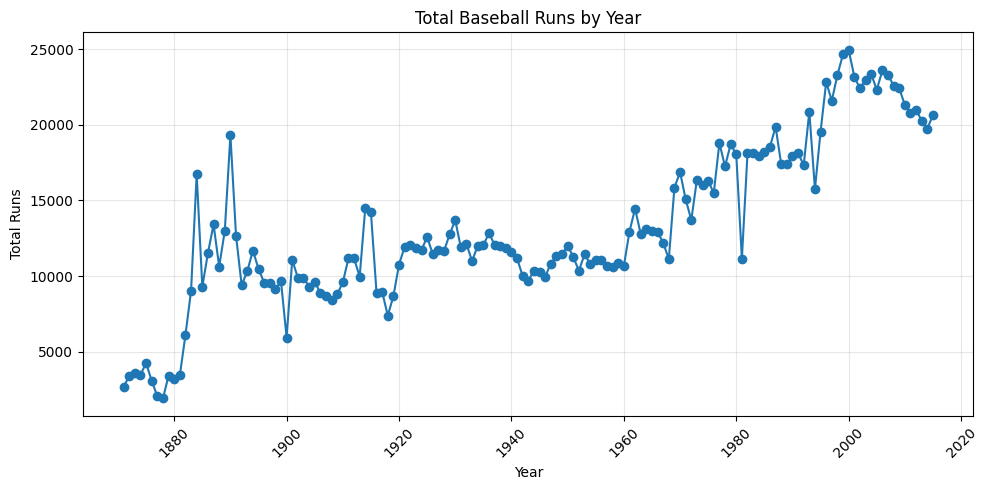

In [6]:
season_runs = df.groupby("yearID", as_index=False)["R"].sum()
plt.figure(figsize=(10,5))
plt.plot(season_runs["yearID"], season_runs["R"], marker="o")
plt.title("Total Baseball Runs by Year")
plt.xlabel("Year")
plt.ylabel("Total Runs")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Experiment_6B_Baseball_Season_Line.png", dpi=150, bbox_inches="tight")
plt.show()

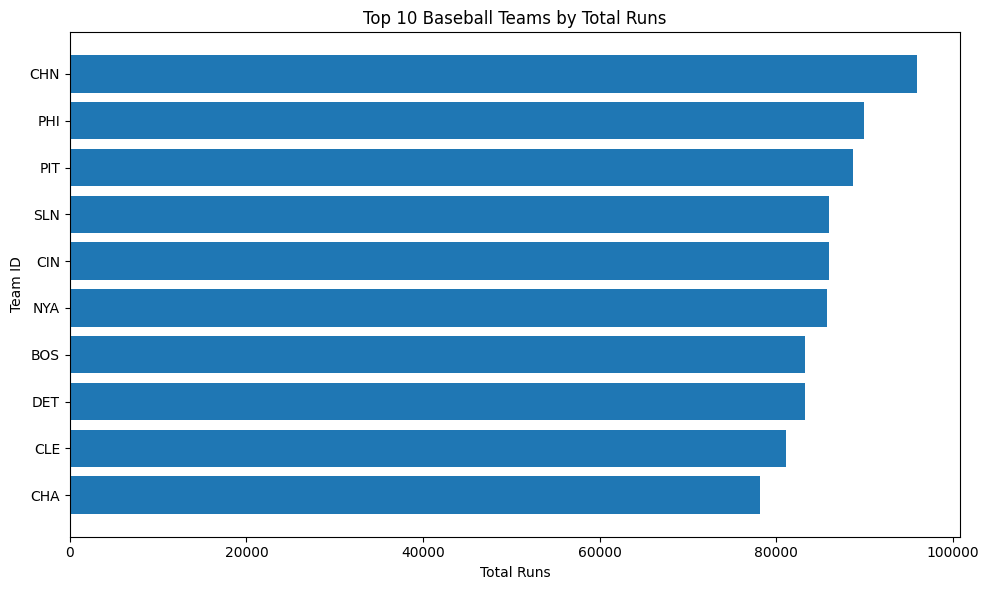

In [7]:
team_runs = df.groupby("teamID", as_index=False)["R"].sum().sort_values("R", ascending=False).head(10)
plt.figure(figsize=(10,6))
plt.barh(team_runs["teamID"][::-1], team_runs["R"][::-1])
plt.title("Top 10 Baseball Teams by Total Runs")
plt.xlabel("Total Runs")
plt.ylabel("Team ID")
plt.tight_layout()
plt.savefig("Experiment_6B_Baseball_Team_Bar.png", dpi=150, bbox_inches="tight")
plt.show()

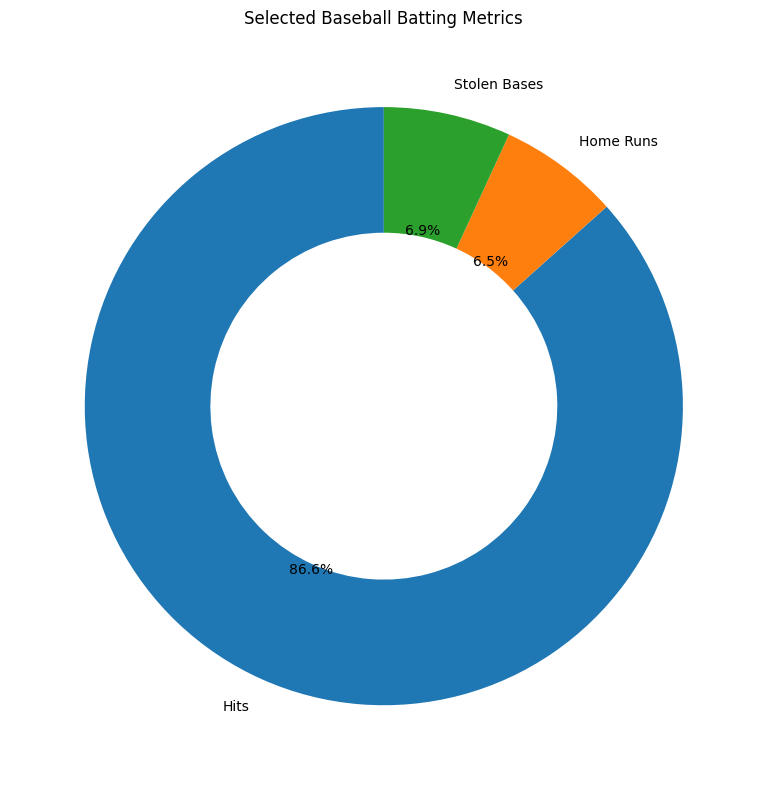

In [8]:
metric_counts = pd.Series({"Hits": df["H"].sum(), "Home Runs": df["HR"].sum(), "Stolen Bases": df["SB"].sum()})
plt.figure(figsize=(8,8))
plt.pie(metric_counts.values, labels=metric_counts.index, autopct="%1.1f%%", startangle=90, wedgeprops={"width":0.42})
plt.title("Selected Baseball Batting Metrics")
plt.tight_layout()
plt.savefig("Experiment_6B_Baseball_Metric_Donut.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
year_summary = df.groupby("yearID")["R"].sum().reset_index()
print("Highest run-producing years:")
print(year_summary.nlargest(10, "R").to_string(index=False))

Highest run-producing years:
 yearID       R
   2000 24971.0
   1999 24691.0
   2006 23599.0
   2004 23376.0
   2007 23322.0
   1998 23297.0
   2001 23199.0
   2003 22978.0
   1996 22831.0
   2008 22585.0


In [10]:
dax_measures = {
    "Total Runs": "Total Runs = SUM(Batting[R])",
    "Total Players": "Total Players = DISTINCTCOUNT(Batting[playerID])",
    "Total Records": "Total Records = COUNTROWS(Batting)",
    "Total Home Runs": "Total Home Runs = SUM(Batting[HR])"
}
for name, formula in dax_measures.items():
    print(name + ":")
    print(formula + "\n")

Total Runs:
Total Runs = SUM(Batting[R])

Total Players:
Total Players = DISTINCTCOUNT(Batting[playerID])

Total Records:
Total Records = COUNTROWS(Batting)

Total Home Runs:
Total Home Runs = SUM(Batting[HR])

